In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

In [ ]:
n = 300

prices = [100]

for i in range(1, n):

    prev = prices[-1]

    shock = np.random.normal(0, 1)

    mean_reversion = 0.05 * (100 - prev)

    new_price = prev + mean_reversion + shock

    prices.append(new_price)

df = pd.DataFrame({
    'Price': prices
})
print(df)

          Price
0    100.000000
1    100.496714
2    100.333614
3    100.964622
4    102.439421
..          ...
295   99.584609
296   98.912469
297   99.866445
298  100.180422
299  100.984263

[300 rows x 1 columns]


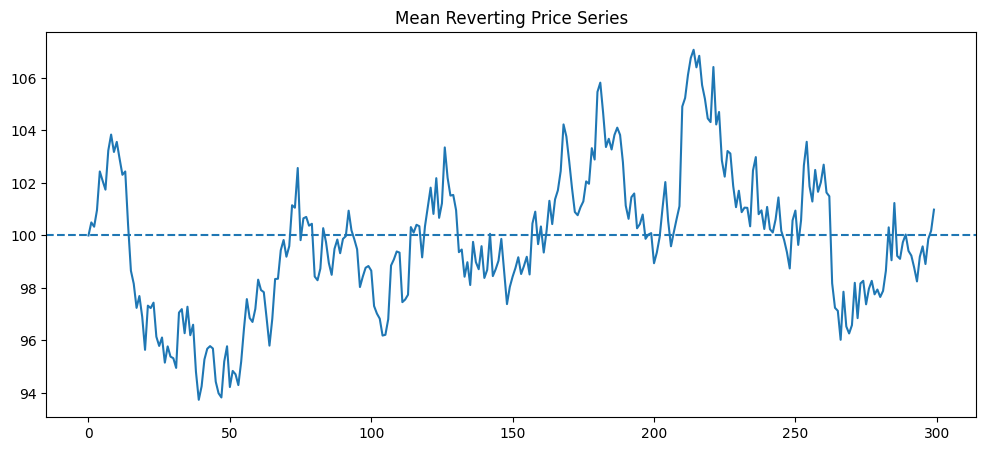

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(df['Price'])

plt.axhline(
    y=100,
    linestyle='--'
)

plt.title("Mean Reverting Price Series")

plt.show()

In [ ]:
window = 20

df['RollingMean'] = (
    df['Price']
    .rolling(window)
    .mean()
)

In [ ]:
df['RollingStd'] = (
    df['Price']
    .rolling(window)
    .std()
)

In [ ]:
df['ZScore'] = (
    (df['Price'] - df['RollingMean'])
    / df['RollingStd']
)

In [ ]:
df['Signal'] = 0

df.loc[
    df['ZScore'] < -2,
    'Signal'
] = 1

df.loc[
    df['ZScore'] > 2,
    'Signal'
] = -1

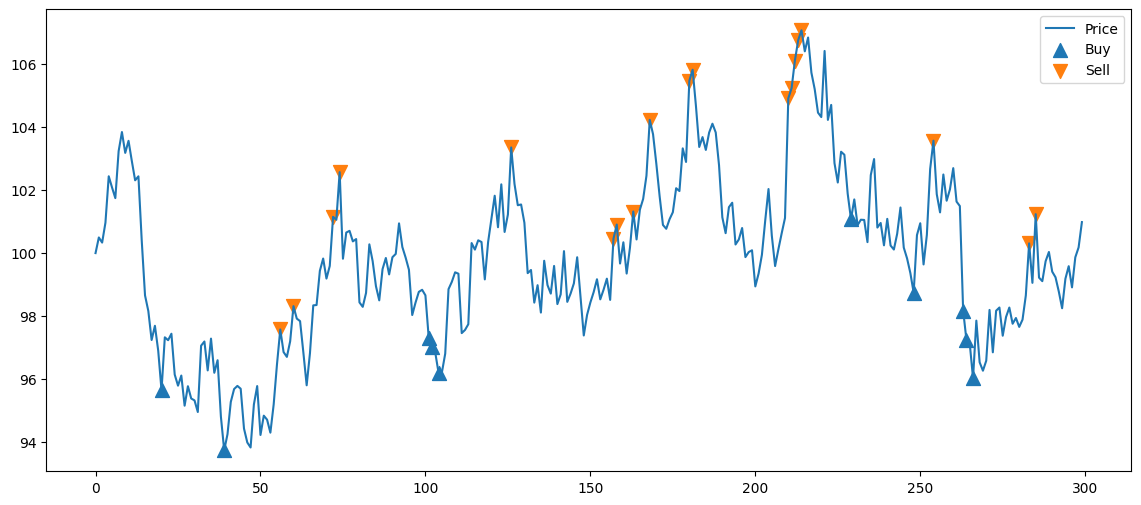

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(
    df['Price'],
    label='Price'
)

plt.scatter(
    df.index[df['Signal']==1],
    df['Price'][df['Signal']==1],
    marker='^',
    s=100,
    label='Buy'
)

plt.scatter(
    df.index[df['Signal']==-1],
    df['Price'][df['Signal']==-1],
    marker='v',
    s=100,
    label='Sell'
)

plt.legend()

plt.show()